In [3]:
#pip install dataframe_image

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#import excel file as dataframe
path = 'experiment2.xlsx'

df = pd.read_excel(path)
display(df)

,dx,fa,fca,fm,fod,fstd,kpr,kts,ra,re,skew,sod,sre,std,thp,vf,measured_wearout
0,-0.001289,2.663847,0.999934,2.665995,-0.000551,0.318094,4.705564e-04,1.702961,1.010218,-0.000552,0.368385,-0.000258,0.000014,0.871461,4.776665,0.000118,0.000009
1,0.008592,2.663418,0.999544,2.665136,-0.000390,0.312170,-1.613751e-04,1.703196,1.011351,-0.000394,0.369652,0.000161,0.000014,0.871675,4.795186,0.000172,0.000019
2,0.000859,2.667714,0.999097,2.669432,-0.000447,0.313127,7.990418e-04,1.703843,1.012152,-0.000451,0.370704,-0.000057,0.000014,0.871644,4.812202,0.000007,0.000028
3,0.006014,2.668143,0.999011,2.669862,-0.000086,0.311842,8.030953e-05,1.703120,1.012471,-0.000091,0.371012,0.000362,0.000016,0.871709,4.816780,0.000082,0.000037
4,0.006014,2.671150,0.998886,2.672869,-0.000125,0.311300,5.621430e-04,1.704503,1.012467,-0.000125,0.372448,-0.000039,0.000016,0.872011,4.836065,0.000082,0.000047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52795,0.000430,6.205764,2.320943,6.208771,0.000748,0.669501,2.078768e-04,1.516066,1.012215,0.000912,0.413400,0.001002,0.000107,2.230308,11.161249,0.000684,0.573394
52796,0.021050,6.206193,2.321137,6.208771,0.000193,0.669536,-6.758364e-08,1.516179,1.012553,0.000592,0.413540,-0.000555,0.000109,2.230288,11.216442,0.000161,0.573420
52797,0.011169,6.216503,2.323080,6.219510,0.001944,0.670287,8.620371e-04,1.516339,1.012891,0.002104,0.413849,0.001751,0.000152,2.232297,11.252382,0.000963,0.573447
52798,0.012458,6.222088,2.324222,6.225095,0.001142,0.670828,4.501379e-04,1.517427,1.012820,0.002297,0.414566,-0.000802,0.000153,2.233641,11.359997,0.000641,0.573473


In [5]:
condition_count_null = df.aggregate(lambda x: x.isnull().sum())
display (condition_count_null)

dx                  0
fa                  0
fca                 0
fm                  0
fod                 0
fstd                0
kpr                 0
kts                 0
ra                  0
re                  0
skew                0
sod                 0
sre                 0
std                 0
thp                 0
vf                  0
measured_wearout    0
dtype: int64

In [6]:
# Prepare data for regression
X = df.drop('measured_wearout', axis = 1) 
y = df['measured_wearout']

# Split the polynomial features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns = X_train.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns = X_test.columns)

In [7]:
# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print(X_train_poly[:1])  # Display the first feature set

# Create and train a polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model.intercept_)  # Display the intercept of the model
print("model coefficient:")  # Display model coefficients
print(poly_reg_model.coef_.round(2))

# Make predictions 
poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

# Calculate and display model performance metrics
mae=mean_absolute_error(y_test, poly_reg_y_predicted) 
mse=mean_squared_error(y_test, poly_reg_y_predicted) 
rmse=np.sqrt(mse)
r2=r2_score(y_test, poly_reg_y_predicted)

print('r2: ', round(r2,4))
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))

[[ 0.40867089 -0.19481671 -0.32088908 -0.19477281 -0.94017566 -0.11920165
   0.96896181  0.96108727 -0.40142831 -1.23781206  1.33735394  0.4366556
   0.18845236 -0.27509747  0.4654954  -0.56934132  0.16701189 -0.07961592
  -0.13113802 -0.07959798 -0.38422242 -0.04871425  0.39598648  0.39276839
  -0.16405206 -0.50585775  0.54653762  0.17844843  0.077015   -0.11242433
   0.19023442 -0.23267322  0.03795355  0.06251455  0.037945    0.18316193
   0.02322247 -0.18876995 -0.18723586  0.07820494  0.24114647 -0.2605389
  -0.08506781 -0.03671367  0.05359358 -0.09068628  0.1109172   0.1029698
   0.06250047  0.3016921   0.03825051 -0.31092926 -0.30840241  0.12881396
   0.39720037 -0.42914227 -0.14011801 -0.06047231  0.08827577 -0.14937239
   0.18269541  0.03793645  0.18312065  0.02321724 -0.18872741 -0.18719366
   0.07818732  0.24109213 -0.26048018 -0.08504864 -0.0367054   0.05358151
  -0.09066585  0.11089221  0.88393028  0.11207049 -0.91099431 -0.90359086
   0.37741313  1.16376077 -1.25734763 -0.

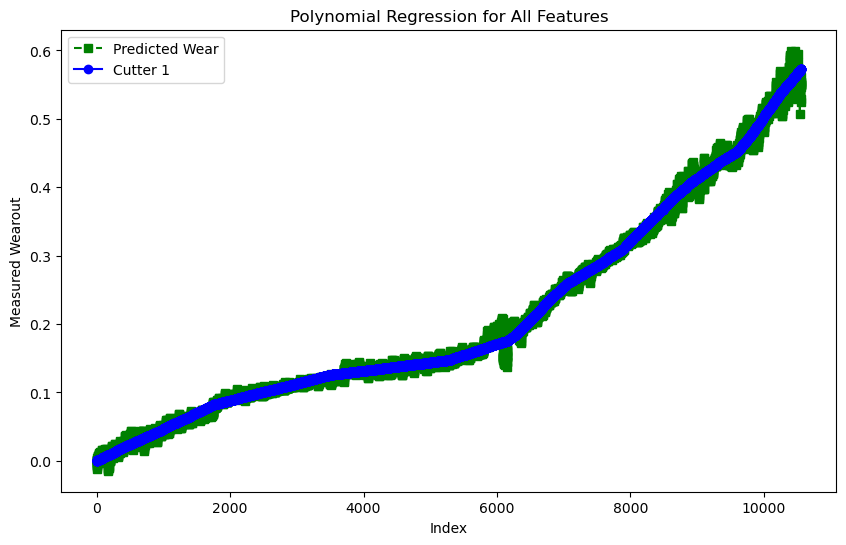

In [8]:
df = pd.DataFrame()
df["y_test"] = y_test 
df["poly_predict"] = poly_reg_y_predicted 
# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for All Features')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')

plt.legend()

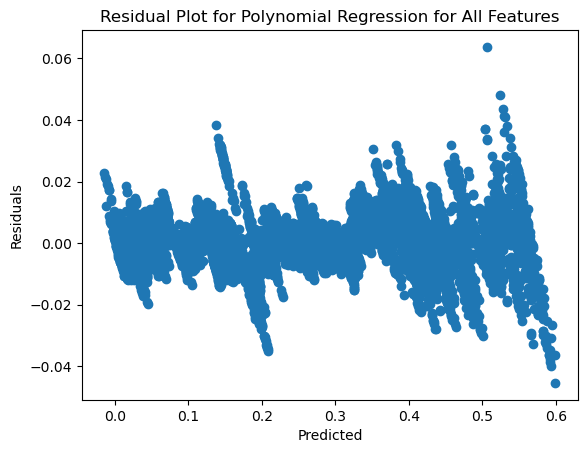

In [9]:
# Residual plot for Polynomial Regression for All Features

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - poly_reg_y_predicted

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted , y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for All Features')

# Show the plot
plt.show()

In [10]:
# Build and fit the multi-linear regression model
model = LinearRegression(fit_intercept=True)
model.fit(X_train_scaled, y_train)

# model coefficients
print("Coefficients: ", np.round(model.coef_, 2))
# model intercept
print("intercept: ", np.round(model.intercept_,2))
print("\n")
#predict using the test data
multi_pred = model.predict(X_test_scaled)

# Calculate and display model performance metrics
mae_multi = mean_absolute_error(y_test, multi_pred) 
mse_multi = mean_squared_error(y_test, multi_pred) 
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, multi_pred)

print('r2_multi: ', round(r2_multi,4))
print('Mean Absolute Error(MAE)_multi: ', round(mae_multi,4))
print('Mean Squared Error(MSE)_multi: ', round(mse_multi,4))
print('Root Mean Squared Error(RMSE)_multi: ', round(rmse_multi,4))

Coefficients:  [-0.    0.66  0.69 -0.81 -0.01  0.2   0.   -0.09  0.    0.    0.06  0.
  0.   -0.62 -0.02  0.  ]
intercept:  0.21


r2_multi:  0.9702
Mean Absolute Error(MAE)_multi:  0.0188
Mean Squared Error(MSE)_multi:  0.0007
Root Mean Squared Error(RMSE)_multi:  0.0257


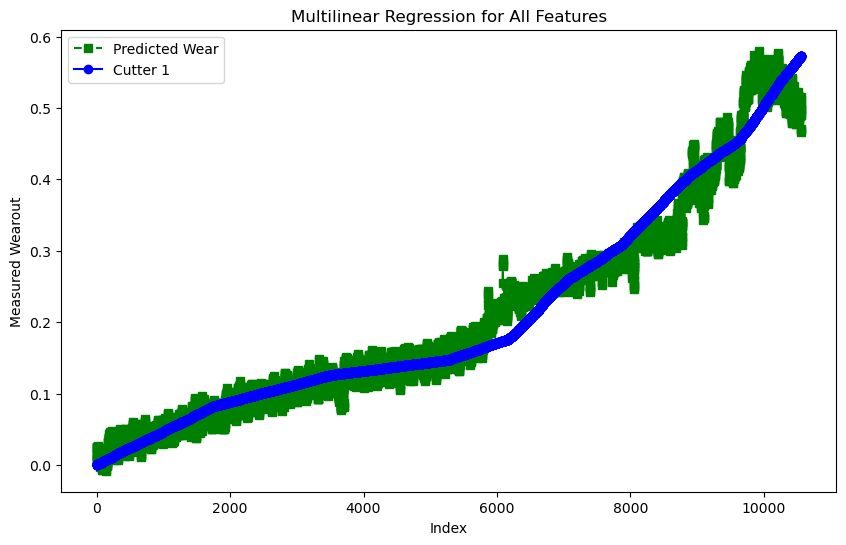

In [11]:
df = pd.DataFrame()
df["y_test"] = y_test 
df["multi_pred"] = multi_pred 
# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df= df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_pred'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for All Features')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

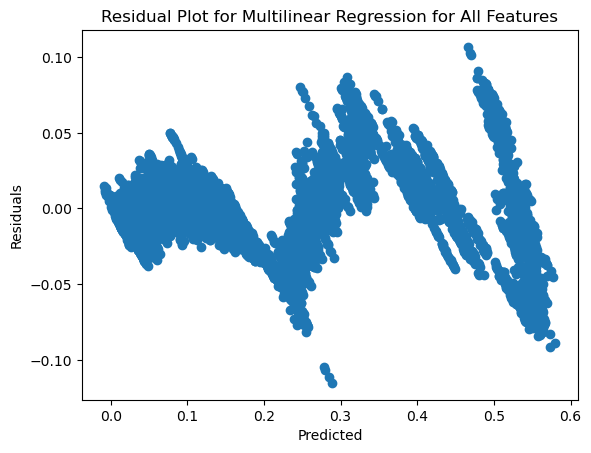

In [12]:
# Residual plot for Multilinear Regression for All Features

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - multi_pred

# Create a scatter plot for residuals vs predicted values
plt.scatter(multi_pred, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for All Features')

# Show the plot
plt.show()

In [13]:
#POLY CORRELATION
# Feature Selection Based on Correlation with Target Variable

df_train = pd.concat([X_train, y_train], axis=1)
r2_poly_corr_list = []
corr_list = [] 

# Compute the correlation matrix
corr = df_train.corr(method='pearson')

#Apply the background gradient for better visualization and display it
styled_corr = corr.style.background_gradient(cmap='coolwarm')
display(styled_corr)
i = 0
for i in np.arange(0, 1,0.05):
    # Selecting features with absolute correlation with respect to 'y' column (target)
    selected_features = list(df_train.loc[:, abs(df_train.corr()['measured_wearout']) > i].drop('measured_wearout', axis=1).columns)
    print("\nFor correalation threshold",round(i,2))
    # Print the selected features
    print("Selected Features:", selected_features)
    #use only selected features for regression 
    X_train_scaled_selected = X_train_scaled[selected_features]
    X_test_scaled_selected = X_test_scaled[selected_features] 
    # Create polynomial features of degree 2 without including bias (intercept) term
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled_selected)
    X_test_poly = poly.transform(X_test_scaled_selected)
    # Create and train a polynomial regression model
    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_train_poly, y_train)
    print("Intercept: %.2f" % poly_reg_model.intercept_)  # Display the intercept of the model
    # Make predictions 
    poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

    # Calculate and display model performance metrics
    mae = mean_absolute_error(y_test, poly_reg_y_predicted) 
    mse = mean_squared_error(y_test, poly_reg_y_predicted) 
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, poly_reg_y_predicted)
    r2 = round(r2,4)
    i = round(i,2)
    r2_poly_corr_list.append(r2)
    corr_list.append(i)
    print('r2_corr_poly_selected', r2)
    print('Mean Absolute Error(MAE): ', round(mae,4))
    print('Mean Squared Error(MSE): ', round(mse,4))
    print('Root Mean Squared Error(RMSE): ', round(rmse,4))

,dx,fa,fca,fm,fod,fstd,kpr,kts,ra,re,skew,sod,sre,std,thp,vf,measured_wearout
dx,1.000000,-0.018239,-0.017325,-0.018220,0.149090,-0.021160,0.234543,0.020512,0.023847,0.146947,0.014647,0.024931,-0.061975,-0.018294,-0.031534,-0.037458,-0.019298
fa,-0.018239,1.000000,0.993623,0.999998,-0.021330,0.969605,-0.008251,-0.452119,-0.341322,-0.022289,0.018369,-0.001279,0.414202,0.996296,0.210472,0.012727,0.950914
fca,-0.017325,0.993623,1.000000,0.993645,-0.019644,0.941931,-0.010438,-0.541167,-0.339616,-0.020906,-0.076374,-0.002192,0.418912,0.998311,0.118171,0.015835,0.969306
fm,-0.018220,0.999998,0.993645,1.000000,-0.021312,0.969502,-0.008261,-0.452116,-0.341334,-0.022274,0.018597,-0.001273,0.414206,0.996291,0.210154,0.012716,0.950999
fod,0.149090,-0.021330,-0.019644,-0.021312,1.000000,-0.027289,0.177464,0.023821,0.013070,0.936797,0.012618,0.420957,-0.138302,-0.023557,-0.067966,0.166666,-0.024575
fstd,-0.021160,0.969605,0.941931,0.969502,-0.027289,1.000000,-0.010798,-0.312320,-0.348721,-0.026056,0.141889,0.000064,0.406684,0.957000,0.418210,0.009574,0.887417
kpr,0.234543,-0.008251,-0.010438,-0.008261,0.177464,-0.010798,1.000000,0.017934,0.081696,0.169079,0.013682,0.058549,-0.060718,-0.010705,-0.012965,0.015933,-0.013484
kts,0.020512,-0.452119,-0.541167,-0.452116,0.023821,-0.312320,0.017934,1.000000,0.126993,0.029157,0.815433,0.005163,-0.295589,-0.521744,0.483417,-0.036749,-0.618713
ra,0.023847,-0.341322,-0.339616,-0.341334,0.013070,-0.348721,0.081696,0.126993,1.000000,0.013854,-0.043630,0.003480,-0.072772,-0.341565,-0.091631,0.004304,-0.315043
re,0.146947,-0.022289,-0.020906,-0.022274,0.936797,-0.026056,0.169079,0.029157,0.013854,1.000000,0.014784,0.139736,-0.214806,-0.024854,-0.062115,0.060671,-0.026767



For correalation threshold 0.0
Selected Features: ['dx', 'fa', 'fca', 'fm', 'fod', 'fstd', 'kpr', 'kts', 'ra', 're', 'skew', 'sod', 'sre', 'std', 'thp', 'vf']
Intercept: 0.21
r2_corr_poly_selected 0.9972
Mean Absolute Error(MAE):  0.0056
Mean Squared Error(MSE):  0.0001
Root Mean Squared Error(RMSE):  0.0079

For correalation threshold 0.05
Selected Features: ['fa', 'fca', 'fm', 'fstd', 'kts', 'ra', 'skew', 'sre', 'std']
Intercept: 0.22
r2_corr_poly_selected 0.9962
Mean Absolute Error(MAE):  0.0064
Mean Squared Error(MSE):  0.0001
Root Mean Squared Error(RMSE):  0.0093

For correalation threshold 0.1
Selected Features: ['fa', 'fca', 'fm', 'fstd', 'kts', 'ra', 'skew', 'sre', 'std']
Intercept: 0.22
r2_corr_poly_selected 0.9962
Mean Absolute Error(MAE):  0.0064
Mean Squared Error(MSE):  0.0001
Root Mean Squared Error(RMSE):  0.0093

For correalation threshold 0.15
Selected Features: ['fa', 'fca', 'fm', 'fstd', 'kts', 'ra', 'sre', 'std']
Intercept: 0.21
r2_corr_poly_selected 0.9942
Mean A

In [14]:
#MULTI CORRELATION
# Feature Selection Based on Correlation with Target Variable
df1_train = pd.concat([X_train, y_train], axis=1)
r2_multi_corr_list = []
# Compute the correlation matrix
corr_multi = df1_train.corr(method='pearson')
# Apply the background gradient for better visualization and display it
styled_corr_multi = corr_multi.style.background_gradient(cmap='coolwarm')
display(styled_corr_multi)

for i in np.arange(0, 1,0.05):
    selected_features_corr_multi = list(df1_train.loc[:, abs(df1_train.corr()['measured_wearout']) > i].drop('measured_wearout', axis=1).columns)
    print("\nFor correalation threshold",round(i,2))
    
    # Print the selected features
    print("Selected Features_corr_multi:", selected_features_corr_multi)
    
    #use only selected features for regression 
    X_train_scaled_selected = X_train_scaled[selected_features_corr_multi]
    X_test_scaled_selected = X_test_scaled[selected_features_corr_multi]
    
    # Build and fit the linear regression model
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train_scaled_selected, y_train)
    
    # model coefficients
    print("Coefficients: ", np.round(model.coef_, 2))
    # model intercept
    print("intercept: ", np.round(model.intercept_,2))
    
    #predict using the test data
    y1_pred = model.predict(X_test_scaled_selected)
    
    # Calculate and display model performance metrics
    mae_corr_multi_selected = mean_absolute_error(y_test, y1_pred) 
    mse_corr_multi_selected = mean_squared_error(y_test, y1_pred) 
    rmse_corr_multi_selected = np.sqrt(mse_corr_multi_selected)
    r2_corr_multi_selected = r2_score(y_test, y1_pred)
    r2_corr_multi_selected = round(r2_corr_multi_selected,4) 
    r2_multi_corr_list.append(r2_corr_multi_selected)
    
    print('r2_corr_multi_selected: ', round(r2_corr_multi_selected,4))
    print('Mean Absolute Error(MAE)_corr_multi_selected: ', round(mae_corr_multi_selected,4))
    print('Mean Squared Error(MSE)_corr_multi_selected: ', round(mse_corr_multi_selected,4))
    print('Root Mean Squared Error(RMSE)_corr_multi_selected: ', round(rmse_corr_multi_selected,4))

,dx,fa,fca,fm,fod,fstd,kpr,kts,ra,re,skew,sod,sre,std,thp,vf,measured_wearout
dx,1.000000,-0.018239,-0.017325,-0.018220,0.149090,-0.021160,0.234543,0.020512,0.023847,0.146947,0.014647,0.024931,-0.061975,-0.018294,-0.031534,-0.037458,-0.019298
fa,-0.018239,1.000000,0.993623,0.999998,-0.021330,0.969605,-0.008251,-0.452119,-0.341322,-0.022289,0.018369,-0.001279,0.414202,0.996296,0.210472,0.012727,0.950914
fca,-0.017325,0.993623,1.000000,0.993645,-0.019644,0.941931,-0.010438,-0.541167,-0.339616,-0.020906,-0.076374,-0.002192,0.418912,0.998311,0.118171,0.015835,0.969306
fm,-0.018220,0.999998,0.993645,1.000000,-0.021312,0.969502,-0.008261,-0.452116,-0.341334,-0.022274,0.018597,-0.001273,0.414206,0.996291,0.210154,0.012716,0.950999
fod,0.149090,-0.021330,-0.019644,-0.021312,1.000000,-0.027289,0.177464,0.023821,0.013070,0.936797,0.012618,0.420957,-0.138302,-0.023557,-0.067966,0.166666,-0.024575
fstd,-0.021160,0.969605,0.941931,0.969502,-0.027289,1.000000,-0.010798,-0.312320,-0.348721,-0.026056,0.141889,0.000064,0.406684,0.957000,0.418210,0.009574,0.887417
kpr,0.234543,-0.008251,-0.010438,-0.008261,0.177464,-0.010798,1.000000,0.017934,0.081696,0.169079,0.013682,0.058549,-0.060718,-0.010705,-0.012965,0.015933,-0.013484
kts,0.020512,-0.452119,-0.541167,-0.452116,0.023821,-0.312320,0.017934,1.000000,0.126993,0.029157,0.815433,0.005163,-0.295589,-0.521744,0.483417,-0.036749,-0.618713
ra,0.023847,-0.341322,-0.339616,-0.341334,0.013070,-0.348721,0.081696,0.126993,1.000000,0.013854,-0.043630,0.003480,-0.072772,-0.341565,-0.091631,0.004304,-0.315043
re,0.146947,-0.022289,-0.020906,-0.022274,0.936797,-0.026056,0.169079,0.029157,0.013854,1.000000,0.014784,0.139736,-0.214806,-0.024854,-0.062115,0.060671,-0.026767



For correalation threshold 0.0
Selected Features_corr_multi: ['dx', 'fa', 'fca', 'fm', 'fod', 'fstd', 'kpr', 'kts', 'ra', 're', 'skew', 'sod', 'sre', 'std', 'thp', 'vf']
Coefficients:  [-0.    0.66  0.69 -0.81 -0.01  0.2   0.   -0.09  0.    0.    0.06  0.
  0.   -0.62 -0.02  0.  ]
intercept:  0.21
r2_corr_multi_selected:  0.9702
Mean Absolute Error(MAE)_corr_multi_selected:  0.0188
Mean Squared Error(MSE)_corr_multi_selected:  0.0007
Root Mean Squared Error(RMSE)_corr_multi_selected:  0.0257

For correalation threshold 0.05
Selected Features_corr_multi: ['fa', 'fca', 'fm', 'fstd', 'kts', 'ra', 'skew', 'sre', 'std']
Coefficients:  [ 0.54  0.67 -0.72  0.14 -0.08  0.    0.05  0.   -0.51]
intercept:  0.21
r2_corr_multi_selected:  0.9686
Mean Absolute Error(MAE)_corr_multi_selected:  0.0194
Mean Squared Error(MSE)_corr_multi_selected:  0.0007
Root Mean Squared Error(RMSE)_corr_multi_selected:  0.0264

For correalation threshold 0.1
Selected Features_corr_multi: ['fa', 'fca', 'fm', 'fstd', 

,Correlation Threshold,R2_Poly,R2_Multi
0,0.00,0.9972,0.9702
1,0.05,0.9962,0.9686
2,0.10,0.9962,0.9686
3,0.15,0.9942,0.9553
4,0.20,0.9942,0.9553
5,0.25,0.9942,0.9553
6,0.30,0.9942,0.9553
7,0.35,0.9941,0.9552
8,0.40,0.9941,0.9552
9,0.45,0.9940,0.9551


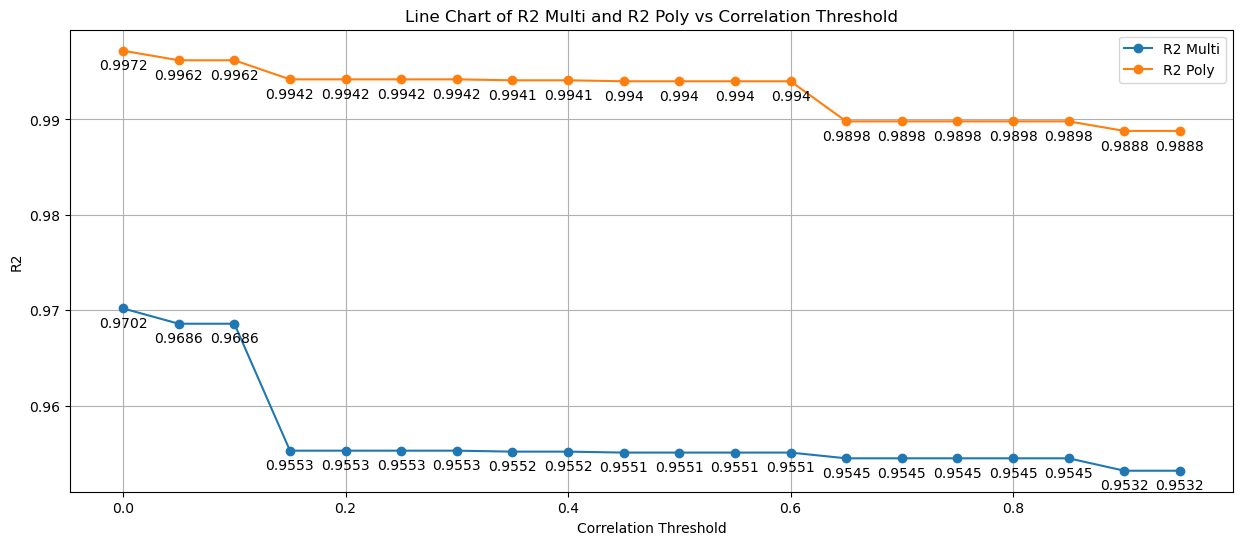

In [15]:
# converting recorded r2 values into data frame and presenting as line graph
df_corr = pd.DataFrame({ 'Correlation Threshold': corr_list, 'R2_Poly': r2_poly_corr_list, 'R2_Multi': r2_multi_corr_list,})

display(df_corr)
# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_corr['Correlation Threshold'], df_corr['R2_Multi'], label='R2 Multi', marker='o', linestyle='-')
plt.plot(df_corr['Correlation Threshold'], df_corr['R2_Poly'], label='R2 Poly', marker='o', linestyle='-')

# Labels and title
for i in range(20):
    plt.text(corr_list[i], r2_poly_corr_list[i]-0.002, r2_poly_corr_list[i], ha = 'center')
for i in range(20):
    plt.text(corr_list[i], r2_multi_corr_list[i]-0.002, r2_multi_corr_list[i], ha = 'center')

plt.xlabel('Correlation Threshold')
plt.ylabel('R2')
plt.title('Line Chart of R2 Multi and R2 Poly vs Correlation Threshold')
plt.legend()

# Show plot
plt.grid(True)
plt.show()

For correalation threshold 0.6
Selected Features: ['fa', 'fca', 'fm', 'fstd', 'kts', 'std']
Intercept: 0.21
r2_corr_poly_selected:  0.994
Mean Absolute Error(MAE):  0.0087
Mean Squared Error(MSE):  0.0001
Root Mean Squared Error(RMSE):  0.0116




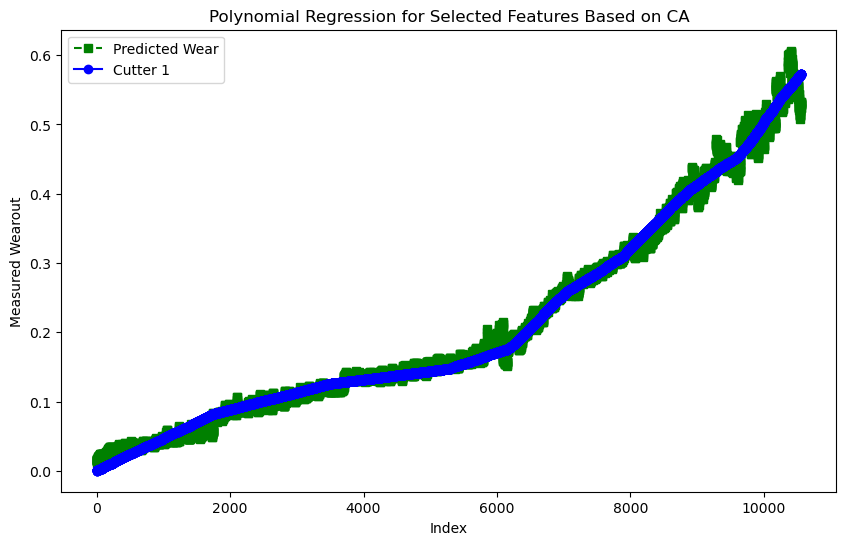

In [16]:
#SELECTED CA THRESHOLD poly MODELING
# Selecting features with absolute correlation with 0.6 respect to 'y' column (target)
selected_features = list(df_train.loc[:, abs(df_train.corr()['measured_wearout']) > 0.6].drop('measured_wearout', axis=1).columns)    
print("For correalation threshold",0.6)
# Print the selected features
print("Selected Features:", selected_features)
#use only selected features for regression 
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features] 
# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_selected)
X_test_poly = poly.transform(X_test_scaled_selected)
# Create and train a polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model.intercept_)  # Display the intercept of the model
# Make predictions 
poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test, poly_reg_y_predicted) 
mse = mean_squared_error(y_test, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2_corr_poly_selected: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["poly_predict"] = poly_reg_y_predicted 

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected Features Based on CA')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

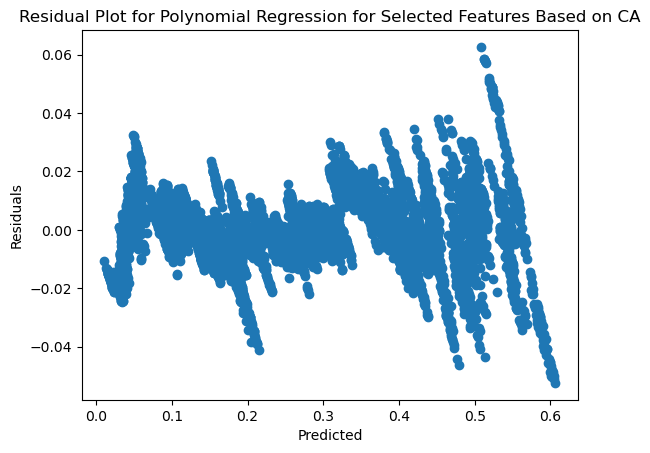

In [17]:
# Residual plot for Polynomial Regression for Selected Features Based on CA

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - poly_reg_y_predicted

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected Features Based on CA')

# Show the plot
plt.show()


For correalation threshold 0.85
Selected Features_corr_multi: ['fa', 'fca', 'fm', 'fstd', 'std']
intercept:  0.21
r2_corr_multi_selected:  0.9545
Mean Absolute Error(MAE)_corr_multi_selected:  0.024
Mean Squared Error(MSE)_corr_multi_selected:  0.001
Root Mean Squared Error(RMSE)_corr_multi_selected:  0.0318


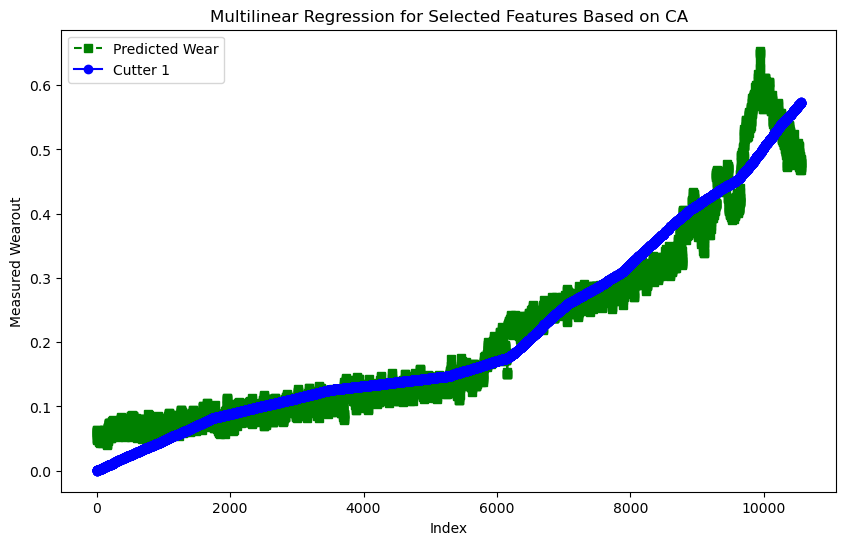

In [18]:
#selected threshold for multi modeling
selected_features_corr_multi = list(df1_train.loc[:, abs(df1_train.corr()['measured_wearout']) > 0.85].drop('measured_wearout', axis=1).columns)
print("\nFor correalation threshold",0.85)
    
# Print the selected features
print("Selected Features_corr_multi:", selected_features_corr_multi)
    
#use only selected features for regression 
X_train_scaled_selected = X_train_scaled[selected_features_corr_multi]
X_test_scaled_selected = X_test_scaled[selected_features_corr_multi]
    
# Build and fit the linear regression model
model = LinearRegression(fit_intercept=True)
model.fit(X_train_scaled_selected, y_train)
    
# model coefficients
#print("Coefficients: ", np.round(model.coef_, 2))
# model intercept
print("intercept: ", np.round(model.intercept_,2))
    
#predict using the test data
y1_pred = model.predict(X_test_scaled_selected)
    
# Calculate and display model performance metrics
mae_corr_multi_selected = mean_absolute_error(y_test, y1_pred) 
mse_corr_multi_selected = mean_squared_error(y_test, y1_pred) 
rmse_corr_multi_selected = np.sqrt(mse_corr_multi_selected)
r2_corr_multi_selected = r2_score(y_test, y1_pred)
r2_corr_multi_selected = round(r2_corr_multi_selected,4) 

    
print('r2_corr_multi_selected: ', round(r2_corr_multi_selected,4))
print('Mean Absolute Error(MAE)_corr_multi_selected: ', round(mae_corr_multi_selected,4))
print('Mean Squared Error(MSE)_corr_multi_selected: ', round(mse_corr_multi_selected,4))
print('Root Mean Squared Error(RMSE)_corr_multi_selected: ', round(rmse_corr_multi_selected,4))

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["multi_pred"] = y1_pred 

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_pred'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected Features Based on CA')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

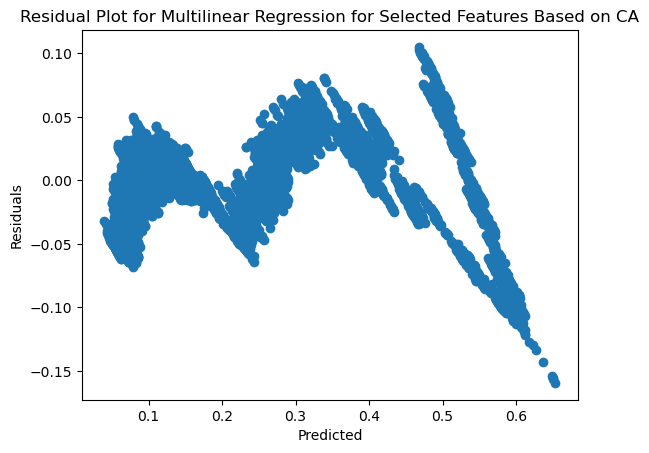

In [19]:
# Residual plot for Multilinear Regression for Selected Features Based on CA

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - y1_pred 

# Create a scatter plot for residuals vs predicted values
plt.scatter(y1_pred, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected Features Based on CA')

# Show the plot
plt.show()

In [20]:
#POLY RFE
# Feature Selection Using Recursive Feature Elimination (RFE) with Linear Regression

# Initialize the linear regression estimator
estimator = LinearRegression()
r2_poly_RFE_list = []
RFE_list = []
# Initialize RFE (Recursive Feature Elimination) with the estimator
for a in range(16):
    # n_features_to_select from 1 to 16 parameters
    selector = RFE(estimator, n_features_to_select = a+1)

    # Fit RFE to the training data and transform X_train to select the top features
    X_selected = selector.fit_transform(X_train_scaled, y_train)

    # Get the indices of the selected features (True values in the support_ array)
    selected_indices = np.where(selector.support_)[0]

    # retrieve the column names for the selected features
    selected_features = [X_train_scaled.columns[i] for i in selected_indices]

    # Print the selected features
    print("\nSelected Features:", selected_features)
    #use only selected features for regression 
    X_train_scaled_selected = X_train_scaled[selected_features]
    X_test_scaled_selected = X_test_scaled[selected_features] 
    # Create polynomial features of degree 2 without including bias (intercept) term
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled_selected)
    X_test_poly = poly.transform(X_test_scaled_selected)
    # Create and train a polynomial regression model
    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_train_poly, y_train)
    print("Intercept: %.2f" % poly_reg_model.intercept_)  # Display the intercept of the model
    # Make predictions 
    poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

    # Calculate and display model performance metrics
    mae = mean_absolute_error(y_test, poly_reg_y_predicted) 
    mse = mean_squared_error(y_test, poly_reg_y_predicted) 
    rmse=np.sqrt(mse)
    r2 = r2_score(y_test, poly_reg_y_predicted)
    r2 =  round(r2,4)
    
    r2_poly_RFE_list.append(r2)
    RFE_list.append(a+1)
    
    print('r2_RFE_poly: ', r2)
    print('Mean Absolute Error(MAE): ', round(mae,4))
    print('Mean Squared Error(MSE): ', round(mse,4))
    print('Root Mean Squared Error(RMSE): ', round(rmse,4))


Selected Features: ['fm']
Intercept: 0.24
r2_RFE_poly:  0.9699
Mean Absolute Error(MAE):  0.0214
Mean Squared Error(MSE):  0.0007
Root Mean Squared Error(RMSE):  0.0259

Selected Features: ['fa', 'fm']
Intercept: 0.24
r2_RFE_poly:  0.9703
Mean Absolute Error(MAE):  0.0212
Mean Squared Error(MSE):  0.0007
Root Mean Squared Error(RMSE):  0.0257

Selected Features: ['fa', 'fca', 'fm']
Intercept: 0.23
r2_RFE_poly:  0.9804
Mean Absolute Error(MAE):  0.016
Mean Squared Error(MSE):  0.0004
Root Mean Squared Error(RMSE):  0.0209

Selected Features: ['fa', 'fca', 'fm', 'fstd']
Intercept: 0.22
r2_RFE_poly:  0.9886
Mean Absolute Error(MAE):  0.0126
Mean Squared Error(MSE):  0.0003
Root Mean Squared Error(RMSE):  0.0159

Selected Features: ['fa', 'fca', 'fm', 'fstd', 'std']
Intercept: 0.22
r2_RFE_poly:  0.9898
Mean Absolute Error(MAE):  0.0118
Mean Squared Error(MSE):  0.0002
Root Mean Squared Error(RMSE):  0.0151

Selected Features: ['fa', 'fca', 'fm', 'fstd', 'kts', 'std']
Intercept: 0.21
r2_RF

In [ ]:
# Feature Selection Using Recursive Feature Elimination (RFE) with Linear Regression
from sklearn.feature_selection import RFE
# Initialize the linear regression estimator
estimator = LinearRegression()
r2_multi_RFE_list = []

# Initialize RFE (Recursive Feature Elimination) with the estimator
for a in range(16):
    # n_features_to_select from 1 to 16 parameters
    selector = RFE(estimator, n_features_to_select = a+1)
    # Fit RFE to the training data and transform X_train to select the top features
    X_selected = selector.fit_transform(X_train_scaled, y_train)
    # Get the indices of the selected features (True values in the support_ array)
    selected_indices = np.where(selector.support_)[0]
    # retrieve the column names for the selected features
    selected_features = [X_train_scaled.columns[i] for i in selected_indices]
    # Print the selected features
    print("\nSelected Features_RFE_multi:", selected_features)
    #use only selected features for regression 
    X_train_scaled_selected = X_train_scaled[selected_features]
    X_test_scaled_selected = X_test_scaled[selected_features] 
    # Build and fit the linear regression model
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train_scaled_selected, y_train)
    # model coefficients
    print("Coefficients: ", np.round(model.coef_, 2))
    # model intercept
    print("intercept: ", np.round(model.intercept_,2))
    #predict using the test data
    y_multi_pred = model.predict(X_test_scaled_selected)

    # Calculate and display model performance metrics
    mae_RFE_multi = mean_absolute_error(y_test, y_multi_pred) 
    mse_RFE_multi = mean_squared_error(y_test, y_multi_pred) 
    rmse_RFE_multi = np.sqrt(mse_RFE_multi)
    r2_RFE_multi = r2_score(y_test, y_multi_pred)
    r2_RFE_multi = round(r2_RFE_multi,4)
    r2_multi_RFE_list.append(r2_RFE_multi)
    
    print('r2_RFE_multi: ',r2_RFE_multi)
    print('Mean Absolute Error(MAE)_RFE_multi: ', round(mae_RFE_multi,4))
    print('Mean Squared Error(MSE)_corr_multi: ', round(mse_RFE_multi,4))
    print('Root Mean Squared Error(RMSE)_corr_multi: ', round(rmse_RFE_multi,4))

In [ ]:
# converting recorded r2 values into data frame and presenting as line graph

df_corr = pd.DataFrame({ 'Number of parameters': RFE_list, 'R2_Poly': r2_poly_RFE_list, 'R2_Multi': r2_multi_RFE_list,})

display(df_corr)
# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_corr['Number of parameters'], df_corr['R2_Multi'], label='R2 Multi', marker='o', linestyle='-')
plt.plot(df_corr['Number of parameters'], df_corr['R2_Poly'], label='R2 Poly', marker='o', linestyle='-')

# Labels and title
for i in range(16):
    plt.text(i+1, r2_poly_RFE_list[i]-0.003, r2_poly_RFE_list[i], ha = 'center')
for i in range(16):
    plt.text(i+1, r2_multi_RFE_list[i]-0.003, r2_multi_RFE_list[i], ha = 'center')
plt.xlabel('Number of parameters')
plt.ylabel('R2')
plt.title('Line Chart of R2 Multi and R2 Poly vs Number of parameters')
plt.legend()

# Show plot
plt.grid(True)
plt.show()

In [ ]:
# selected feature of 6 for poly model
selector = RFE(estimator, n_features_to_select = 6)

# Fit RFE to the training data and transform X_train to select the top features
X_selected = selector.fit_transform(X_train_scaled, y_train)

# Get the indices of the selected features (True values in the support_ array)
selected_indices = np.where(selector.support_)[0]

# retrieve the column names for the selected features
selected_features = [X_train_scaled.columns[i] for i in selected_indices]

# Print the selected features
print("Selected Features:", selected_features)
#use only selected features for regression 
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features] 
# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_selected)
X_test_poly = poly.transform(X_test_scaled_selected)
# Create and train a polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model.intercept_)  # Display the intercept of the model
# Make predictions 
poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test, poly_reg_y_predicted) 
mse = mean_squared_error(y_test, poly_reg_y_predicted) 
rmse=np.sqrt(mse)
r2 = r2_score(y_test, poly_reg_y_predicted)
r2 =  round(r2,4)
    
r2_poly_RFE_list.append(r2)

print('r2_RFE_poly: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["poly_predict"] = poly_reg_y_predicted 

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected Features Based on RFE')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

In [ ]:
# Residual plot for Polynomial Regression for Selected Features Based on RFE

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected Features Based on RFE')

# Show the plot
plt.show()

In [ ]:
# selected feature of 7 for multi model
selector = RFE(estimator, n_features_to_select = 7)

# Fit RFE to the training data and transform X_train to select the top features
X_selected = selector.fit_transform(X_train_scaled, y_train)

# Get the indices of the selected features (True values in the support_ array)
selected_indices = np.where(selector.support_)[0]

# retrieve the column names for the selected features
selected_features = [X_train_scaled.columns[i] for i in selected_indices]

# Print the selected features
print("Selected Features_RFE_multi:", selected_features)
#use only selected features for regression 
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features] 
# Build and fit the linear regression model
model = LinearRegression(fit_intercept=True)
model.fit(X_train_scaled_selected, y_train)
# model coefficients
print("Coefficients: ", np.round(model.coef_, 2))
# model intercept
print("intercept: ", np.round(model.intercept_,2))
#predict using the test data
y_multi_pred = model.predict(X_test_scaled_selected)

# Calculate and display model performance metrics
mae_RFE_multi = mean_absolute_error(y_test, y_multi_pred) 
mse_RFE_multi = mean_squared_error(y_test, y_multi_pred) 
rmse_RFE_multi = np.sqrt(mse_RFE_multi)
r2_RFE_multi = r2_score(y_test, y_multi_pred)
r2_RFE_multi = round(r2_RFE_multi,4)
    
print('r2_RFE_multi: ',r2_RFE_multi)
print('Mean Absolute Error(MAE)_RFE_multi: ', round(mae_RFE_multi,4))
print('Mean Squared Error(MSE)_corr_multi: ', round(mse_RFE_multi,4))
print('Root Mean Squared Error(RMSE)_corr_multi: ', round(rmse_RFE_multi,4))
print('\n')

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["multi_predict"] = y_multi_pred

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected Features Based on RFE')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

In [ ]:
# Residual plot for Multilinear Regression for Selected Features Based on RFE

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - y_multi_pred 

# Create a scatter plot for residuals vs predicted values
plt.scatter(y_multi_pred, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected Features Based on RFE')

# Show the plot
plt.show()

In [ ]:
# Apply PCA:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Explained variance ratio
explained_variance_ratio = np.round(pca.explained_variance_ratio_ * 100, decimals=2)
print("Explained Variance Ratio (%):")
print(explained_variance_ratio)

# Cumulative explained variance
cumulative_explained_variance = np.round(np.cumsum(explained_variance_ratio), decimals=2)
print("\nCumulative Explained Variance (%):")
print(cumulative_explained_variance)

#Scree Plot:
plt.figure(figsize=(15, 6))
plt.bar(x= range(1,len(explained_variance_ratio)+1), height=explained_variance_ratio)
plt.ylabel('Percentate of Variance Explained')
plt.xlabel('Principal Component')
plt.title('PCA Scree Plot')
for i in range(16):
    plt.text(i+1, explained_variance_ratio[i], explained_variance_ratio[i], ha = 'center')
plt.show()

# Calculate PCA Loadings
loadings = pca.components_.T
loading_df = pd.DataFrame(loadings, index=X_train.columns, columns=[f'PC{i + 1}' for i in range(loadings.shape[1])])
print("\nPCA Loadings:")
display(loading_df)



#PCA with poly regression modeling
# Loop through increasing numbers of principal components (from 1 to 16)
max_components = 16
rmse_poly_list = []
r2_PCA_poly_list = []
n_components_list = []
for n_components in range(1, max_components + 1):
    print(f"\nUsing {n_components} Principal Component(s)")
    
    # Select the first n_components from the PCA transformed data
    X_train_pca_n = X_train_pca[:, :n_components]
    X_test_pca_n = X_test_pca[:, :n_components]

    # Create polynomial features of degree 2 without including bias (intercept) term
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_pca_n)
    X_test_poly = poly.transform( X_test_pca_n)
    # Create and train a polynomial regression model
    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_train_poly, y_train)
    # Make predictions 
    poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, poly_reg_y_predicted))
    r2 = r2_score(y_test, poly_reg_y_predicted)
    r2 = round(r2,4)
    
    # Store the results
    rmse_poly_list.append(rmse)
    r2_PCA_poly_list.append(r2)
    n_components_list.append(n_components)
    # Print the performance metrics for the current number of components
    print(f"Root Mean Squared Error (RMSE): {round(rmse,2)}")
    print(f"R-squared (R²) poly: {r2}")


In [ ]:
#PCA with multi-linear regression
# Loop through increasing numbers of principal components (from 1 to 16)
max_components = 16
rmse_multi_list = []
r2_PCA_multi_list = []

for n_components in range(1, max_components + 1):
    print(f"\nUsing {n_components} Principal Component(s)")
    
    # Select the first n_components from the PCA transformed data
    X_train_pca_n = X_train_pca[:, :n_components]
    X_test_pca_n = X_test_pca[:, :n_components]
    
    # Train the linear regression model using the selected principal components
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_pca_n, y_train)
    
    # Predict on the test set
    y_multi_pred = lin_reg.predict(X_test_pca_n)
    
    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_multi_pred))
    r2 = r2_score(y_test, y_multi_pred)
    r2 = round(r2,4)
    
    # Store the results
    rmse_multi_list.append(rmse)
    r2_PCA_multi_list.append(r2)
    
    # Print the performance metrics for the current number of components
    print(f"Root Mean Squared Error (RMSE): {round(rmse,2)}")
    print(f"R-squared (R²) multi: {r2}")

In [ ]:
# converting recorded r2 values into data frame and presenting as line graph

df_corr = pd.DataFrame({ 'Number of principal components': n_components_list, 'R2_Poly': r2_PCA_poly_list, 'R2_Multi': r2_PCA_multi_list,})

display(df_corr)
# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_corr['Number of principal components'], df_corr['R2_Multi'], label='R2 Multi', marker='o', linestyle='-')
plt.plot(df_corr['Number of principal components'], df_corr['R2_Poly'], label='R2 Poly', marker='o', linestyle='-')

# Labels and title
for i in range(16):
    plt.text(i+1, r2_PCA_poly_list[i]-0.003, r2_PCA_poly_list[i], ha = 'center')
for i in range(16):
    plt.text(i+1, r2_PCA_multi_list[i]-0.003, r2_PCA_multi_list[i], ha = 'center')
plt.xlabel('Number of principal components')
plt.ylabel('R2')
plt.title('Line Chart of R2 Multi and R2 Poly vs Number of principal components')
plt.legend()

# Show plot
plt.grid(True)
plt.show()

In [ ]:
#selected 12 PCA for poly
print(f"\nUsing {12} Principal Component(s)")
    
# Select the first 12 from the PCA transformed data
X_train_pca_n = X_train_pca[:, :12]
X_test_pca_n = X_test_pca[:, :12]

# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_pca_n)
X_test_poly = poly.transform( X_test_pca_n)
# Create and train a polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)
# Make predictions 
poly_reg_y_predicted = poly_reg_model.predict(X_test_poly)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test, poly_reg_y_predicted) 
mse = mean_squared_error(y_test, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["poly_predict"] = poly_reg_y_predicted 

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected PCs')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

In [ ]:
# Residual plot for Polynomial Regression for Selected PCs

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected PCs')

# Show the plot
plt.show()

In [ ]:
#selected 11 PCA for linear
print(f"\nUsing {11} Principal Component(s)")
    
# Select the first 11 from the PCA transformed data
X_train_pca_n = X_train_pca[:, :11]
X_test_pca_n = X_test_pca[:, :11]
    
# Train the linear regression model using the selected principal components
lin_reg = LinearRegression()
lin_reg.fit(X_train_pca_n, y_train)
    
# Predict on the test set
y_multi_pred = lin_reg.predict(X_test_pca_n)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test, y_multi_pred) 
mse = mean_squared_error(y_test, y_multi_pred) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_multi_pred)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test 
df["multi_pred"] = y_multi_pred 

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_pred'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected PCs')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

In [ ]:
# Residual plot for Multilinear Regression for Selected PCs

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test - y_multi_pred 

# Create a scatter plot for residuals vs predicted values
plt.scatter(y_multi_pred, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected PCs')

# Show the plot
plt.show()

In [ ]:
#QUESTION 3

In [ ]:
#import excel file as dataframe
path1 = 'experiment2_1.xlsx'
df_test = pd.read_excel(path1)
display(df_test)

In [ ]:
#ALL PARA FOR POLY
y_test_qn3 = df_test['measured_wearout']

X_train_poly_selected = df_train.drop('measured_wearout', axis = 1) 
X_test_poly_2nd_cutter = df_test.drop('measured_wearout', axis = 1) 

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_poly_selected),columns = X_train_poly_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter_all = pd.DataFrame(scaler.transform(X_test_poly_2nd_cutter),columns = X_test_poly_2nd_cutter.columns)

# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_qn3)
X_test_poly_2nd_cutter = poly.transform(X_test_scaled_2nd_cutter_all)

# Create and train a polynomial regression model
poly_reg_model_corr = LinearRegression()
poly_reg_model_corr.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model_corr.intercept_)  # Display the intercept of the model

# Make predictions 
poly_reg_y_predicted = poly_reg_model_corr.predict(X_test_poly_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, poly_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["poly_predict"] = poly_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for All Features')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Polynomial Regression for All Features

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for All Features')

# Show the plot
plt.show()

In [ ]:
#ALL PARA FOR MULTI
y_test_qn3 = df_test['measured_wearout']

X_train_multi_selected = df_train.drop('measured_wearout', axis = 1) 
X_test_multi_2nd_cutter = df_test.drop('measured_wearout', axis = 1) 

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_multi_selected),columns = X_train_multi_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter = pd.DataFrame(scaler.transform(X_test_multi_2nd_cutter),columns = X_test_multi_2nd_cutter.columns)

#use only selected features for regression 
model = LinearRegression(fit_intercept=True)
model.fit(X_train_multi_selected, y_train)

# Make predictions 
multi_reg_y_predicted = model.predict(X_test_multi_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, multi_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, multi_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, multi_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["multi_predict"] = multi_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for All Features')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Multilinear Regression for All Features

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - multi_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(multi_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for All Features')

# Show the plot
plt.show()

In [ ]:
#CORR 2 CUTTER POLY

y_test_qn3 = df_test['measured_wearout']
selected_features_CA_poly = ['fa', 'fca', 'fm', 'fstd', 'kts', 'std']
print("Selected Features for CA:", selected_features_CA_poly)
#use only selected features for regression 

#use only selected features for regression 

X_train_poly_selected = df_train[selected_features_CA_poly]
X_test_poly_2nd_cutter = df_test[selected_features_CA_poly]

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_poly_selected),columns = X_train_poly_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter = pd.DataFrame(scaler.transform(X_test_poly_2nd_cutter),columns = X_test_poly_2nd_cutter.columns)

# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_qn3)
X_test_poly_2nd_cutter = poly.transform(X_test_scaled_2nd_cutter)

# Create and train a polynomial regression model
poly_reg_model_corr = LinearRegression()
poly_reg_model_corr.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model_corr.intercept_)  # Display the intercept of the model

# Make predictions 
poly_reg_y_predicted = poly_reg_model_corr.predict(X_test_poly_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, poly_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["poly_predict"] = poly_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected Features Based on CA')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Polynomial Regression for Selected Features Based on CA

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected Features Based on CA')

# Show the plot
plt.show()

In [ ]:
#CORR 2 CUTTER MULTI

y_test_qn3 = df_test['measured_wearout']
selected_features_CA_multi = ['fa', 'fca', 'fm', 'fstd', 'std']
print("Selected Features for CA:", selected_features_CA_multi)
#use only selected features for regression 

X_train_multi_selected = df_train[selected_features_CA_multi]
X_test_multi_2nd_cutter = df_test[selected_features_CA_multi]

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_multi_selected),columns = X_train_multi_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter = pd.DataFrame(scaler.transform(X_test_multi_2nd_cutter),columns = X_test_multi_2nd_cutter.columns)

#use only selected features for regression 
model = LinearRegression(fit_intercept=True)
model.fit(X_train_multi_selected, y_train)

# Make predictions 
multi_reg_y_predicted = model.predict(X_test_multi_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, multi_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, multi_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, multi_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["multi_predict"] = multi_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected Features Based on CA')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Multilinear Regression for Selected Features Based on CA

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - multi_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(multi_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected Features Based on CA')

# Show the plot
plt.show()

In [ ]:
#RFE 2 CUTTER POLY

y_test_qn3 = df_test['measured_wearout']
selected_features_RFE_poly = ['fa', 'fca', 'fm', 'fstd', 'kts', 'std']
print("Selected Features for RFE:", selected_features_RFE_poly)
#use only selected features for regression 

X_train_poly_selected = df_train[selected_features_RFE_poly]
X_test_poly_2nd_cutter = df_test[selected_features_RFE_poly]

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_poly_selected),columns = X_train_poly_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter = pd.DataFrame(scaler.transform(X_test_poly_2nd_cutter),columns = X_test_poly_2nd_cutter.columns)

# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_qn3)
X_test_poly_2nd_cutter = poly.transform(X_test_scaled_2nd_cutter)

# Create and train a polynomial regression model
poly_reg_model_corr = LinearRegression()
poly_reg_model_corr.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model_corr.intercept_)  # Display the intercept of the model

# Make predictions 
poly_reg_y_predicted = poly_reg_model_corr.predict(X_test_poly_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, poly_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["poly_predict"] = poly_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected Features Based on RFE')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Polynomial Regression for Selected Features Based on RFE

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected Features Based on RFE')

# Show the plot
plt.show()

In [ ]:
#RFE 2 CUTTER MULTI
y_test_qn3 = df_test['measured_wearout']
selected_features_RFE_multi = ['fa', 'fca', 'fm', 'fstd', 'kts', 'skew', 'std']
print("Selected Features for CA:", selected_features_RFE_multi)
#use only selected features for regression 

X_train_multi_selected = df_train[selected_features_RFE_multi]
X_test_multi_2nd_cutter = df_test[selected_features_RFE_multi]

# Standardizing the features
scaler = StandardScaler()
# Fit the scaler and transform the training data
X_train_scaled_qn3 = pd.DataFrame(scaler.fit_transform(X_train_multi_selected),columns = X_train_multi_selected.columns)
# Apply the scaler to the test data using transform (not fit_transform)
X_test_scaled_2nd_cutter = pd.DataFrame(scaler.transform(X_test_multi_2nd_cutter),columns = X_test_multi_2nd_cutter.columns)

#use only selected features for regression 
model = LinearRegression(fit_intercept=True)
model.fit(X_train_multi_selected, y_train)

# Make predictions 
multi_reg_y_predicted = model.predict(X_test_multi_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, multi_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, multi_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, multi_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["multi_predict"] = multi_reg_y_predicted 
df["cutter_1"] = y_test
# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected Features Based on RFE')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error


In [ ]:
# Residual plot for Multilinear Regression for Selected Features Based on RFE

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - multi_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(multi_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected Features Based on RFE')

# Show the plot
plt.show()

In [ ]:
#poly with select PCs
#selected 12 PCA for poly
print(f"\nUsing {12} Principal Component(s)")
    
# Apply PCA:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled_2nd_cutter_all)

# Select the first 12 from the PCA transformed data
X_train_pca_n = X_train_pca[:, :12]
X_test_pca_n = X_test_pca[:, :12]

# Create polynomial features of degree 2 without including bias (intercept) term
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_pca_n)
X_test_poly_2nd_cutter = poly.transform(X_test_pca_n)

# Create and train a polynomial regression model
poly_reg_model_corr = LinearRegression()
poly_reg_model_corr.fit(X_train_poly, y_train)
print("Intercept: %.2f" % poly_reg_model_corr.intercept_)  # Display the intercept of the model

# Make predictions 
poly_reg_y_predicted = poly_reg_model_corr.predict(X_test_poly_2nd_cutter)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, poly_reg_y_predicted) 
mse = mean_squared_error(y_test_qn3, poly_reg_y_predicted) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, poly_reg_y_predicted)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["poly_predict"] = poly_reg_y_predicted 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['poly_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Polynomial Regression for Selected PCs')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()
#plot error

In [ ]:
# Residual plot for Polynomial Regression for Selected PCs

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - poly_reg_y_predicted 

# Create a scatter plot for residuals vs predicted values
plt.scatter(poly_reg_y_predicted, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Polynomial Regression for Selected PCs')

# Show the plot
plt.show()

In [ ]:
# Select the first 11 from the PCA transformed data
X_train_pca_n = X_train_pca[:, :11]
X_test_pca_n = X_test_pca[:, :11]

# Predict on the test set
y_multi_pred = lin_reg.predict(X_test_pca_n)

# Calculate and display model performance metrics
mae = mean_absolute_error(y_test_qn3, y_multi_pred) 
mse = mean_squared_error(y_test_qn3, y_multi_pred) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test_qn3, y_multi_pred)
r2 = round(r2,4)

print('r2: ', r2)
print('Mean Absolute Error(MAE): ', round(mae,4))
print('Mean Squared Error(MSE): ', round(mse,4))
print('Root Mean Squared Error(RMSE): ', round(rmse,4))
print("\n")

#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["multi_predict"] = y_multi_pred 
df["cutter_1"] = y_test

# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['multi_predict'], color='green', linestyle='--', marker='s', label='Predicted Wear')
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Multilinear Regression for Selected PCs')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()

In [ ]:
# Residual plot for Multilinear Regression for Selected Features Based on RFE

# Calculate residuals (the difference between actual and predicted values)
y_residual = y_test_qn3 - y_multi_pred 

# Create a scatter plot for residuals vs predicted values
plt.scatter(y_multi_pred, y_residual)

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Residuals'
plt.ylabel('Residuals')

# Add a title to the plot
plt.title('Residual Plot for Multilinear Regression for Selected PCs')

# Show the plot
plt.show()

In [ ]:
#create df 
df = pd.DataFrame()
df["y_test"] = y_test_qn3 
df["cutter_1"] = y_test
# Sort the DataFrame by actual 'y_test' values and reset index without adding the index as a column
df = df.sort_values(by="y_test").reset_index(drop=True)

# Plot the sorted values with customized line styles and colors
plt.figure(figsize=(10, 6))
plt.plot(df['y_test'], color='red', linestyle='-', marker='o', label='Cutter 2')
plt.plot(df['cutter_1'], color='blue', linestyle='-', marker='o', label='Cutter 1')
plt.title('Cutter 1 vs. Cutter 2 Wearout')
plt.xlabel('Index')
plt.ylabel('Measured Wearout')
plt.legend()